# Topical Lectures, Controls 
## Drone control, part 4b: test flight (non-interactive)
Andreas Freise, Bas Swinkels 27.05.2026

This notebook (and its interactive twin `student4a`) is where we put the controllers from the previous notebooks to work. If you can we suggest that you use the one with interactive plots (4a) first. Notebooks `student5` and `student6` then explore alternative, model-based controllers on the same task.

In this notebook, we will try to fly our drone, using the controls we developed in the previous notebooks. To make it a bit more fun, we pose the following challenge: fly your drone through a set of predefined markers and report the time. We will compare the best times at the end of the project.

This is an alternative version of the notebook in which we do not use interactive mode but a preprogrammed set of controls to race our drone.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time
import module
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

# inline plots again
%matplotlib inline

# Don't forget to set the name string to your own name
MyName = "Andreas"

Below we set the calibration constants from notebook 2 and provide the motor-mixing helpers. The velocity-loop cascade controllers (same as in notebook 3b) are set up in the next cell.

In [8]:
# Measured parameters for the Crazyflie-scale drone (SI units throughout).
# These would normally come from the student2 system-identification notebook.
V_left_offset = -0.0027   # throttle units; cancels left/right asymmetry
V_hover = 0.5297          # per-motor throttle at hover (= M*g/2 / amp)
V_max = 1.0               # throttle range upper bound
V_min = 0                 # motors are single-direction

# Common-mode / differential decomposition for motor mixing.
# Total motor command must stay in [V_min, V_max]; the differential is
# bounded by the headroom that the common-mode thrust leaves on each side.

def set_v(drone, _V_left, _V_right):
    V_left = V_hover + _V_left + V_left_offset
    V_right = V_hover + _V_right
    fb_z = (V_left + V_right) / 2
    fb_phi = (V_left - V_right) / 2
    fb_z = max(V_min, min(fb_z, V_max))
    headroom = min(fb_z - V_min, V_max - fb_z)
    fb_phi = max(-headroom, min(fb_phi, headroom))
    drone.set_V(fb_z + fb_phi, fb_z - fb_phi)

def set_v_nohover(drone, _V_left, _V_right):
    V_left = _V_left + V_left_offset
    V_right = _V_right
    fb_z = (V_left + V_right) / 2
    fb_phi = (V_left - V_right) / 2
    fb_z = max(V_min, min(fb_z, V_max))
    headroom = min(fb_z - V_min, V_max - fb_z)
    fb_phi = max(-headroom, min(fb_phi, headroom))
    drone.set_V(fb_z + fb_phi, fb_z - fb_phi)

def zphi2V(fb_z, fb_phi):
    V_left = fb_z + fb_phi
    V_right = fb_z - fb_phi
    return V_left, V_right


In [9]:
# Velocity-loop cascade controllers, same as in student3b.
# Position -> velocity -> tilt -> torque.
y_pos_ctrl = module.PIDController(Kp=-2.0, Ki=0,    Kd=0)
z_pos_ctrl = module.PIDController(Kp=-2.0, Ki=0,    Kd=0)
y_vel_ctrl = module.PIDController(Kp=0.5,  Ki=0.02, Kd=0)
z_vel_ctrl = module.PIDController(Kp=-3.0, Ki=-0.3, Kd=0)
phi_ctrl   = module.PIDController(Kp=0.2,  Ki=0,    Kd=0.04)
v_max_cmd  = 1.0                # m/s
tilt_max   = 20 * np.pi / 180   # rad


## Racing your drone

Again, to test our new control loops we are going to race our drone through a simple track. The goal is to reach a pre-defined set of targets as quickly as possible.

Below we run a preprogrammed control loop that steps through the targets in order, switching the setpoints `y0`, `z0` to the next target each time the drone reaches the current one. We collect the trajectory and plot it afterwards, then replay the run as an inline video.

In [10]:
drone = module.Drone(name=MyName, wind=True)

# Defining the track as an array of targets [y, z, radius] in metres.
targets = np.array([
    [ 1.0,  1.5, 0.1],
    [ 1.0, -1.5, 0.1],
    [-1.0, -1.5, 0.1],
    [-1.0,  1.5, 0.1],
    [   0,    0, 0.1]
])
drone.set_targets(targets)

# Running for 200 seconds
N = 200 * 60
Nidx = N - 1
results = np.zeros([N, 14])
V_left = V_right = 0

for ctrl in (y_pos_ctrl, z_pos_ctrl, y_vel_ctrl, z_vel_ctrl, phi_ctrl):
    ctrl.reset()

for i in range(N):
    state = drone.update()
    results[i, 0:12] = module.state_to_array(state)
    results[i, 12:14] = [V_left, V_right]

    idx = drone.target_idx
    if idx == drone.num_targets:
        Nidx = i
        break
    y0 = targets[idx, 0]
    z0 = targets[idx, 1]

    # Outer position loops -> desired velocity, saturated at +-v_max_cmd.
    dy_des = float(np.clip(y_pos_ctrl(state.y, state.dy, y0),
                           -v_max_cmd, v_max_cmd))
    dz_des = float(np.clip(z_pos_ctrl(state.z, state.dz, z0),
                           -v_max_cmd, v_max_cmd))

    # Velocity loops -> desired tilt (y) and thrust correction (z).
    tilt_des = float(np.clip(y_vel_ctrl(state.dy, 0, dy_des),
                             -tilt_max, tilt_max))
    z_corr = z_vel_ctrl(state.dz, 0, dz_des)

    # Inner phi PD tracks the commanded tilt.
    phi_fb = phi_ctrl(state.phi, state.dphi, tilt_des)

    # Mix and send.
    hover_ff = V_hover / np.cos(state.phi)
    V_left, V_right = zphi2V(hover_ff + z_corr, phi_fb)
    set_v_nohover(drone, V_left, V_right)


Total time: 20.00 out of 200.00 seconds


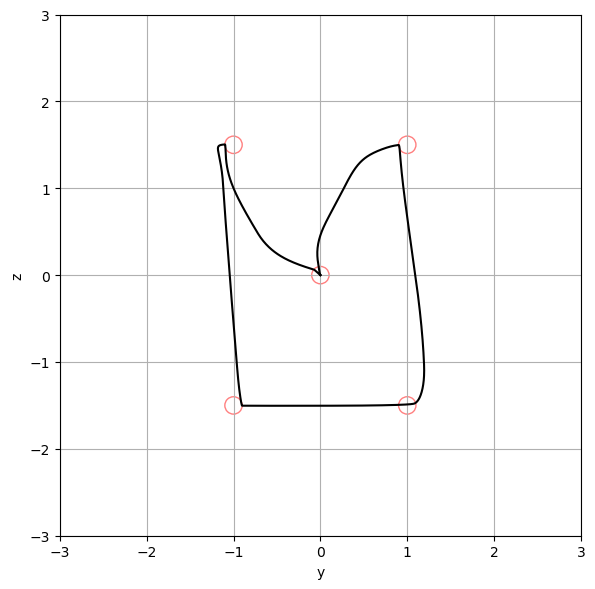

In [11]:
#Plotting the reuslts

start=0
t = results[start:,0]
y = results[start:,1]
z = results[start:,2]
phi = results[start:,3]
dphi = results[start:,6]
fig, ax = plt.subplots(1, figsize=(12,6))
for _t in targets:
    patch = plt.Circle((_t[0],_t[1]),_t[2], lw=1, color='red', alpha=0.5, fill=False)
    ax.add_patch(patch)
plt.plot(y,z, 'k')
ax.set_xlabel("y")
ax.set_ylabel("z")
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
plt.grid()
#plt.legend()
plt.tight_layout()

t_end = results[Nidx,0]

print(f"Total time: {t_end:.2f} out of {N/60.0:.2f} seconds")


## Replay the race as an inline video

The race ran headless above. We can now embed an HTML5 video of the recorded trajectory directly into the notebook output. This works in any browser-based notebook (JupyterLab, classic, VS Code, Google Colab) and does not need a Qt backend.


In [12]:
# Trim the results to the part of the run that actually happened
# (the loop above breaks early and leaves trailing zeros if all
# targets were reached before N steps).
module.render_replay(drone, results[:Nidx + 1])
